# Day 6: Sequence Intelligence
## LSTMs, GRUs, and the Vanishing Gradient Problem
---
**Objective:** Master sequential data by predicting non-linear time series.

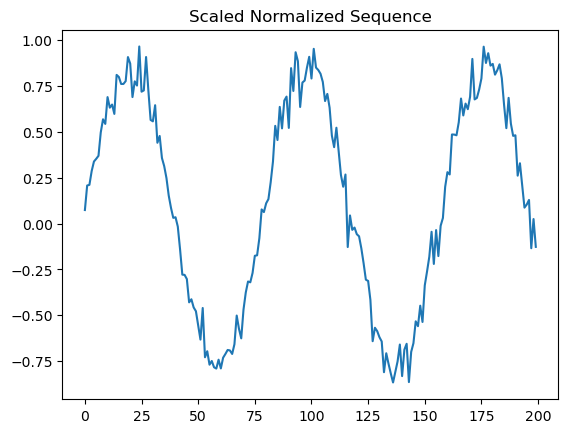

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 6.1 Data Generation with Scaling
t = np.linspace(0, 800, 1000)
series = np.sin(0.1 * t) + np.random.normal(0, 0.1, 1000)

scaler = MinMaxScaler(feature_range=(-1, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1))

plt.plot(series_scaled[:200])
plt.title("Scaled Normalized Sequence")
plt.show()

### 6.2 Sliding Window Logic
We convert the sequence into overlapping windows. This is the standard 'Memory' setup.

In [7]:
def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

window_size = 40
X, y = create_dataset(series_scaled, window_size)
print(f"X Shape: {X.shape} (Samples, Seq_Len, Features)")

X Shape: torch.Size([960, 40, 1]) (Samples, Seq_Len, Features)


### 6.3 LSTM vs GRU Architectures
The GRU (Gated Recurrent Unit) is a faster, simpler version of the LSTM with fewer parameters.

In [8]:
class SequenceModel(nn.Module):
    def __init__(self, mode='LSTM', hidden=64):
        super().__init__()
        if mode == 'LSTM':
            self.rnn = nn.LSTM(1, hidden, batch_first=True)
        else:
            self.rnn = nn.GRU(1, hidden, batch_first=True)
            
        self.fc = nn.Linear(hidden, 1)
        
    def forward(self, x):
        # x shape: (batch, seq, 1)
        out, _ = self.rnn(x)
        # Take the last time step output
        return self.fc(out[:, -1, :])

lstm_model = SequenceModel(mode='LSTM')
gru_model = SequenceModel(mode='GRU')
print("LSTM Total Params:", sum(p.numel() for p in lstm_model.parameters()))
print("GRU Total Params:", sum(p.numel() for p in gru_model.parameters()))

LSTM Total Params: 17217
GRU Total Params: 12929


### 6.4 Vanishing Gradient Test
Let's inspect the gradients of the model's weights after a backward pass to see how well 'memory' is being preserved.

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

outputs = lstm_model(X[:32]) # Test batch
loss = criterion(outputs, y[:32])
loss.backward()

for name, param in lstm_model.named_parameters():
    if 'weight' in name:
        print(f"{name} gradient mean: {param.grad.abs().mean().item():.8f}")

rnn.weight_ih_l0 gradient mean: 0.00694515
rnn.weight_hh_l0 gradient mean: 0.00060190
fc.weight gradient mean: 0.07218713
